In [1]:
from pathlib import Path

import h5py

import matplotlib.pyplot as plt
import numpy as np

from scipy import ndimage

In [2]:
file_path = Path("../results/BIIAX_196(245)_02_tomo-A_recon_crop_ztrim150.seg.h5")

In [3]:
def reassign_enclosed_components(seg, source_label, neighbor_structure=None):
    """
    Reassign connected components of source_label that are completely surrounded
    by exactly one other phase. Fully vectorized — no per-component array scans.
    """
    binary = seg == source_label
    labeled, num_features = ndimage.label(binary, structure=neighbor_structure)

    if num_features == 0:
        return seg.copy()

    if neighbor_structure is None:
        neighbor_structure = ndimage.generate_binary_structure(seg.ndim, seg.ndim)

    border_mask = ndimage.binary_dilation(binary, structure=neighbor_structure) & ~binary
    adj_comp = ndimage.maximum_filter(labeled, footprint=neighbor_structure)

    border_comp = adj_comp[border_mask]
    border_phase = seg[border_mask]

    valid = border_phase != source_label
    border_comp = border_comp[valid]
    border_phase = border_phase[valid]

    pairs = np.unique(np.stack([border_comp, border_phase], axis=1), axis=0)
    n_phases_per_comp = np.bincount(pairs[:, 0], minlength=num_features + 1)

    enclosed_ids = np.where(n_phases_per_comp == 1)[0]
    enclosed_ids = enclosed_ids[enclosed_ids > 0]

    # Build a LUT: component ID → target phase (default: keep source_label)
    lut = np.full(num_features + 1, source_label, dtype=seg.dtype)
    for comp_id in enclosed_ids:
        lut[comp_id] = pairs[pairs[:, 0] == comp_id, 1][0]

    # Apply in a single vectorized pass over source_label voxels only
    seg_out = seg.copy()
    seg_out[binary] = lut[labeled[binary]]

    print(f"Reassigned {len(enclosed_ids)} / {num_features} components of label {source_label}")
    return seg_out


def remove_small_islands(seg, phase_label, min_size=100):
    binary = seg == phase_label
    labeled, num_features = ndimage.label(binary)
    component_sizes = np.bincount(labeled.ravel())

    too_small = component_sizes < min_size
    too_small[0] = False

    remove_mask = too_small[labeled]
    print(f"Components to remove: {too_small.sum()-1} / {num_features}, voxels: {remove_mask.sum()}")

    seg_cleaned = seg.copy()
    _, indices = ndimage.distance_transform_edt(remove_mask, return_indices=True)
    seg_cleaned[remove_mask] = seg[tuple(idx[remove_mask] for idx in indices)]

    return seg_cleaned


def _nearest_neighbor_phase(seg, mask):
    _, indices = ndimage.distance_transform_edt(mask, return_indices=True)
    return seg[tuple(indices[:, mask])]

In [4]:
## laod one slice for prototyping
with h5py.File(file_path, "r") as f:
    seg = f["seg"][:]
print(f"shape of seg: {seg.shape}, unique labels: {np.unique(seg)}")

shape of seg: (1706, 1383, 1383), unique labels: [0 1 2 3]


Reassigned 1509 / 5494 components of label 2


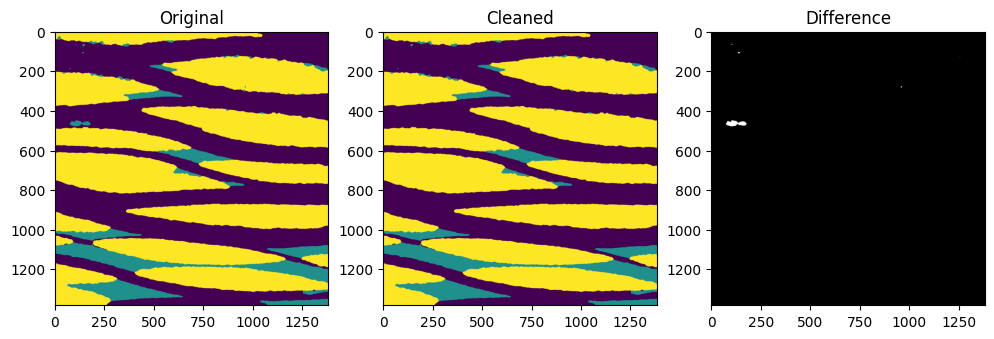

In [5]:
mid = seg.shape[0] // 2

# Step 1: reassign phase-2 components fully enclosed in a single other phase
seg_cleaned = reassign_enclosed_components(seg, source_label=2)


fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].set_title("Original")
ax[0].imshow(seg[mid, ::])
ax[1].set_title("Cleaned")
ax[1].imshow(seg_cleaned[mid, ::])
ax[2].set_title("Difference")
ax[2].imshow(seg[mid, ::] != seg_cleaned[mid, ::], cmap="gray")
plt.show()

In [6]:
# Map old label IDs → new label IDs before saving
# Labels present: [0, 1, 2, 3]
label_assignment = {
    0: 0,
    1: 2,
    2: 1,
    3: 3,
}

seg_out = np.zeros_like(seg_cleaned)
for old_label, new_label in label_assignment.items():
    seg_out[seg_cleaned == old_label] = new_label

print(f"Labels before: {np.unique(seg_cleaned)}, after: {np.unique(seg_out)}")

Labels before: [0 1 2 3], after: [0 1 2 3]


In [7]:
with h5py.File(file_path, "a") as f:
    f["seg_"] = seg_out